Read the data using Pandas

In [71]:
import pandas as pd
players = pd.read_csv('./data/Fifa23Players.csv')
#Drop nationality as we will focus on clubs
players = players.drop('Nationality', axis=1)
print(players.info())

<class 'pandas.DataFrame'>
RangeIndex: 18539 entries, 0 to 18538
Data columns (total 88 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Known As                     18539 non-null  str    
 1   Full Name                    18539 non-null  str    
 2   Overall                      18539 non-null  int64  
 3   Potential                    18539 non-null  int64  
 4   Value(in Euro)               18539 non-null  int64  
 5   Positions Played             18539 non-null  str    
 6   Best Position                18539 non-null  str    
 7   Image Link                   18539 non-null  str    
 8   Age                          18538 non-null  float64
 9   Height(in cm)                18539 non-null  int64  
 10  Weight(in kg)                18539 non-null  int64  
 11  TotalStats                   18539 non-null  int64  
 12  BaseStats                    18539 non-null  int64  
 13  Club Name                  

Will do the stratified sampling

In [72]:
from sklearn.model_selection import StratifiedShuffleSplit
train_set_data = None
test_set_data = None
players['overall_cat'] = pd.cut(players['Overall'], bins=[0, 60, 70, 80, 90, 100], labels=['0-60', '60-70', '70-80', '80-90', '90-100'])
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(players, players['overall_cat']):
    train_set_data = players.iloc[train_index]
    test_set_data = players.iloc[test_index]
print(len(train_set_data))
print(len(test_set_data))

14831
3708


In [73]:
# Remove the 'overall_cat' column from both train and test sets
train_set_data = train_set_data.drop('overall_cat', axis=1)
test_set_data = test_set_data.drop('overall_cat', axis=1)

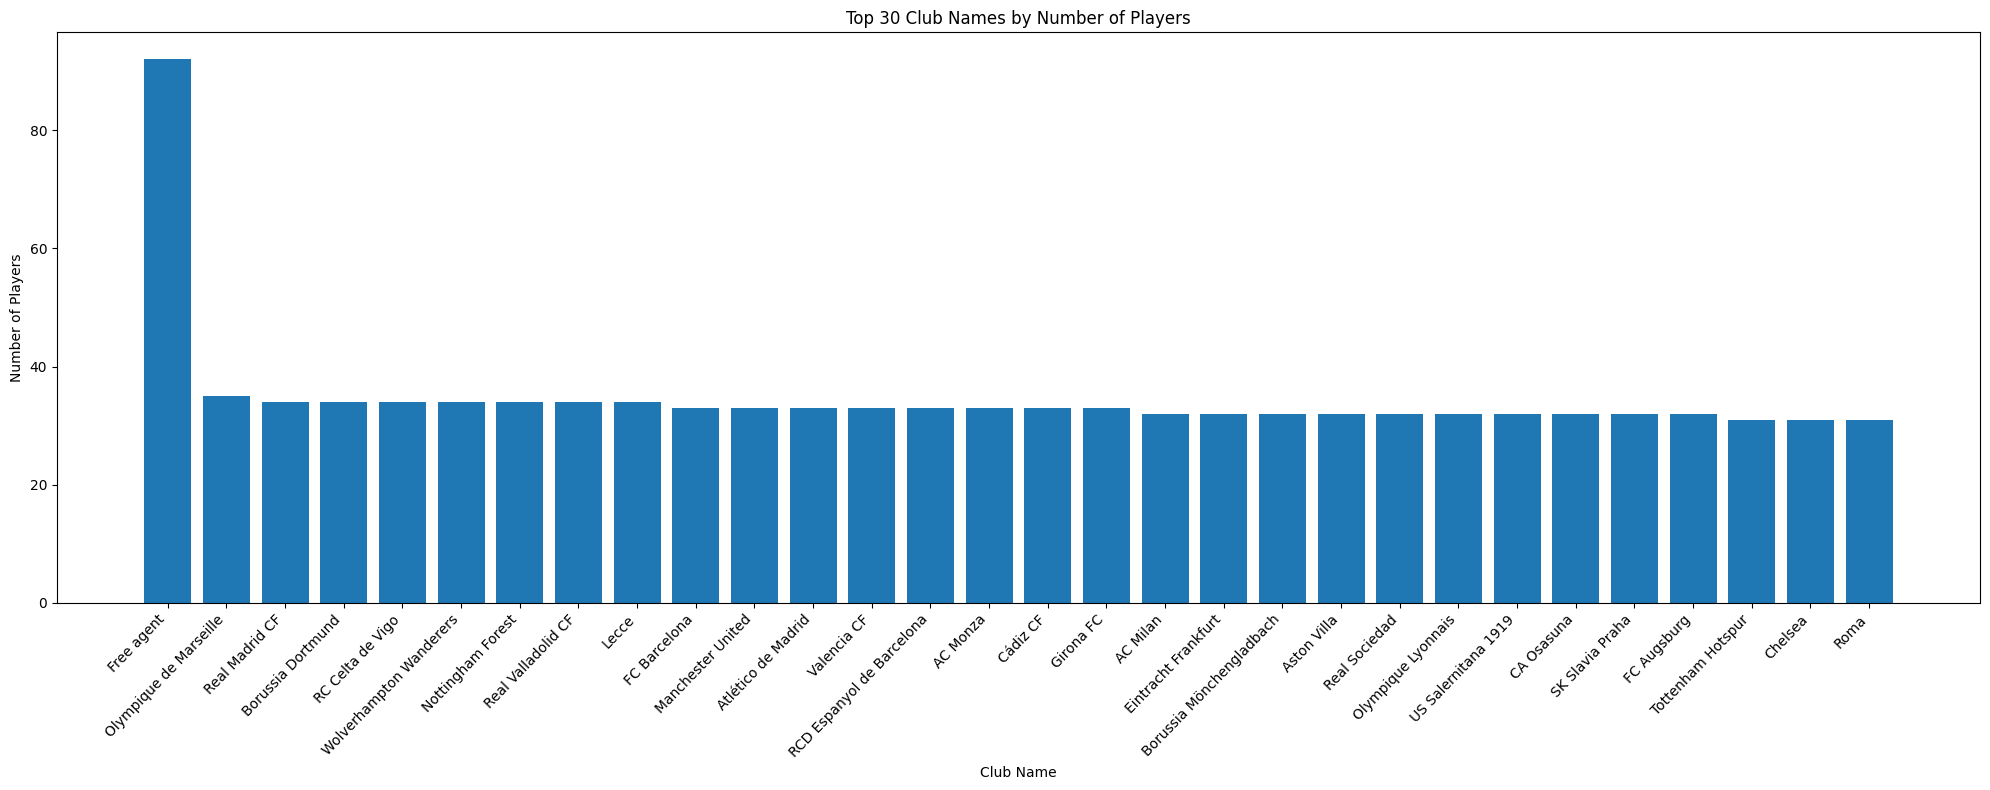

In [74]:
# Create bar chart of top 20 clubs
import matplotlib.pyplot as plt
top_clubs = players['Club Name'].value_counts().head(30)
plt.figure(figsize=(20, 8))
plt.bar(top_clubs.index,top_clubs.values)
plt.xticks(rotation=46, ha='right')
plt.xlabel('Club Name')
plt.ylabel('Number of Players')
plt.title('Top 30 Club Names by Number of Players')
plt.tight_layout()
plt.show()

In [75]:
# Look for correlations between features and the target variable (Value(in Euro))
corr_matrix = train_set_data.corr(numeric_only=True)
print(corr_matrix['Value(in Euro)'].sort_values(ascending=False))

Value(in Euro)              1.000000
Release Clause              0.973817
Wage(in Euro)               0.824109
International Reputation    0.579998
Overall                     0.563463
                              ...   
Goalkeeper Positioning     -0.029049
 GoalkeeperKicking         -0.029126
Goalkeeper Diving          -0.029799
Goalkeeper Handling        -0.030145
Joined On                  -0.122003
Name: Value(in Euro), Length: 71, dtype: float64


In [ ]:
empty_players = players.isnull().any(axis=1)


0        False
1        False
2         True
3        False
4        False
         ...  
18534    False
18535    False
18536    False
18537    False
18538    False
Length: 18539, dtype: bool
